In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from experiments.experiment import Experiment
from models.logistic_regression import LogisticRegressionModel
from models.svm import SVMModel
from models.random_forest import RandomForestModel
from vectorization.bow import BoWVectorizer
from vectorization.tfidf import TfidfVectorizerWrapper

from preprocessing.pipeline import PreprocessingPipeline
from preprocessing.steps.html_removal import HtmlRemovalStep
from preprocessing.steps.hyphen_removal import HyphenRemovalStep
from preprocessing.steps.lowercasing import LowercasingStep
from preprocessing.steps.tokenization import TokenizationStep
from preprocessing.steps.punctuation import PunctuationRemovalStep
from preprocessing.steps.stopwords import StopwordsRemovalStep
from preprocessing.steps.lemmatization import LemmatizationStep

In [ ]:
with open('../results/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

df_train = splits['train']
df_val   = splits['val']
df_test  = splits['test']   # koristim tek u tuningu

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Train: 40,000 | Val: 5,000 | Test: 5,000


In [ ]:
PROJECT_ROOT = os.path.abspath('..')
mlflow.set_tracking_uri(f'file:///{PROJECT_ROOT}/mlruns'.replace('\\', '/'))
mlflow.set_experiment('imdb-sentiment')

<Experiment: artifact_location='file:///c:/Users/Iva/Desktop/imdb-sentiment-classification/mlruns/397932824360539574', creation_time=1779195973368, experiment_id='397932824360539574', last_update_time=1779195973368, lifecycle_stage='active', name='imdb-sentiment', tags={}>

In [ ]:
BEST_MODEL_CLASS    = SVMModel         
BEST_VEC_CLASS      = TfidfVectorizerWrapper
BEST_VEC_NAME       = 'TF-IDF'


In [ ]:
# ablaciona studija  leave one out


ALL_STEPS = [
    ('HtmlRemoval',      HtmlRemovalStep),
    ('HyphenRemoval',    HyphenRemovalStep),
    ('Lowercasing',      LowercasingStep),
    ('Tokenization',     TokenizationStep),
    ('PunctuationRemoval', PunctuationRemovalStep),
    ('StopwordsRemoval', StopwordsRemovalStep),
    ('Lemmatization',    LemmatizationStep),
]


def apply_pipeline(df: pd.DataFrame, steps: list) -> pd.DataFrame:
    step_names = [n for n, _ in steps]
    
    if 'Tokenization' not in step_names:
        pre_tok  = [(n, C) for n, C in steps if n in ('HtmlRemoval', 'HyphenRemoval', 'Lowercasing')]
        post_tok = [(n, C) for n, C in steps if n in ('PunctuationRemoval', 'StopwordsRemoval', 'Lemmatization')]
        
        pre_pipeline  = PreprocessingPipeline(steps=[C() for _, C in pre_tok])
        post_pipeline = PreprocessingPipeline(steps=[C() for _, C in post_tok])
        
        df = df.copy()
        df['cleaned'] = df['review'].apply(
            lambda text: post_pipeline.process(pre_pipeline.process(text).split())
        )
    else:
        pipeline = PreprocessingPipeline(steps=[C() for _, C in steps])
        df = df.copy()
        df['cleaned'] = df['review'].apply(pipeline.process)
    
    return df


mlflow.end_run() 

ablation_results = []

print('Running full-pipeline baseline ...')
df_train_full = apply_pipeline(df_train, ALL_STEPS)
df_val_full   = apply_pipeline(df_val,   ALL_STEPS)

exp_full = Experiment(
    model=BEST_MODEL_CLASS(),
    vectorizer=BEST_VEC_CLASS(),
    run_name='ablation_full_pipeline',
)
exp_full.run(df_train_full, df_val_full, tags={'study': 'ablation', 'removed_step': 'none'})
ablation_results.append({
    'removed_step': 'none (full pipeline)',
    'val_f1': round(exp_full.val_metrics.f1, 4),
})
print(f'  val_f1={ablation_results[-1]["val_f1"]}')

# Leave-one-out
for removed_name, _ in ALL_STEPS:
    mlflow.end_run()  
    remaining = [(n, C) for n, C in ALL_STEPS if n != removed_name]
    print(f'Running without {removed_name} ...', end=' ', flush=True)

    df_train_abl = apply_pipeline(df_train, remaining)
    df_val_abl   = apply_pipeline(df_val,   remaining)

    exp = Experiment(
        model=BEST_MODEL_CLASS(),
        vectorizer=BEST_VEC_CLASS(),
        run_name=f'ablation_no_{removed_name}',
    )
    exp.run(df_train_abl, df_val_abl,
            tags={'study': 'ablation', 'removed_step': removed_name})

    ablation_results.append({
        'removed_step': f'no {removed_name}',
        'val_f1': round(exp.val_metrics.f1, 4),
    })
    print(f'val_f1={ablation_results[-1]["val_f1"]}')

ablation_df = pd.DataFrame(ablation_results).sort_values('val_f1', ascending=False)
ablation_df

Running full-pipeline baseline ...
  val_f1=0.9016
Running without HtmlRemoval ... val_f1=0.9018
Running without HyphenRemoval ... val_f1=0.8982
Running without Lowercasing ... val_f1=0.9015
Running without Tokenization ... val_f1=0.8801
Running without PunctuationRemoval ... val_f1=0.9053
Running without StopwordsRemoval ... val_f1=0.9014
Running without Lemmatization ... val_f1=0.9005


,removed_step,val_f1
5,no PunctuationRemoval,0.9053
1,no HtmlRemoval,0.9018
0,none (full pipeline),0.9016
3,no Lowercasing,0.9015
6,no StopwordsRemoval,0.9014
7,no Lemmatization,0.9005
2,no HyphenRemoval,0.8982
4,no Tokenization,0.8801


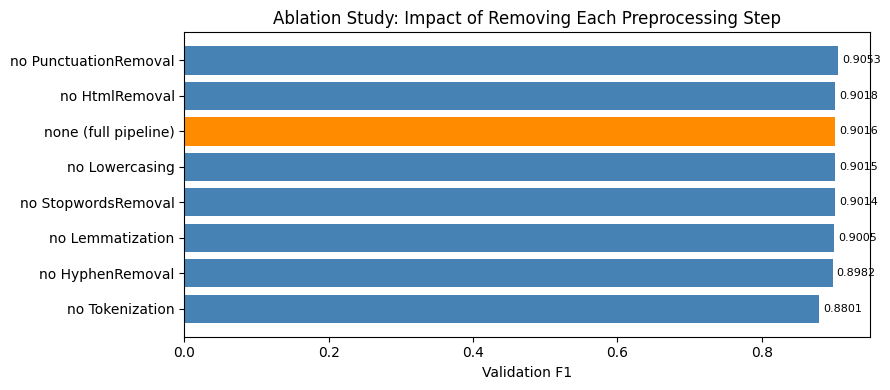

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = [
    'steelblue' if r != 'none (full pipeline)' else 'darkorange'
    for r in ablation_df['removed_step']
]
bars = ax.barh(ablation_df['removed_step'], ablation_df['val_f1'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.set_xlabel('Validation F1')
ax.set_title('Ablation Study: Impact of Removing Each Preprocessing Step')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
NGRAM_RANGES = [(1, 1), (1, 2), (1, 3)]
MIN_DFS      = [1, 5, 10]
MAX_FEATURES = 500_000

vec_tuning_results = []

for ngram_range in NGRAM_RANGES:
    for min_df in MIN_DFS:
        probe_vec = TfidfVectorizerWrapper(ngram_range=ngram_range, min_df=min_df)
        X_probe = probe_vec.fit_transform(df_train)
        n_feat = X_probe.shape[1]

        if n_feat > MAX_FEATURES:
            print(f'SKIP  ngram={ngram_range} min_df={min_df} → {n_feat:,} features > 500 K')
            continue

        run_name = f'vec_tfidf_ngram{ngram_range}_mindf{min_df}'
        print(f'Running {run_name} ({n_feat:,} features) ...', end=' ', flush=True)

        exp = Experiment(
            model=BEST_MODEL_CLASS(),
            vectorizer=TfidfVectorizerWrapper(ngram_range=ngram_range, min_df=min_df),
            run_name=run_name,
        )
        exp.run(
            df_train, df_val,
            tags={'study': 'vectorizer_tuning',
                  'ngram_range': str(ngram_range),
                  'min_df': str(min_df)},
        )

        vec_tuning_results.append({
            'ngram_range': ngram_range,
            'min_df':      min_df,
            'n_features':  n_feat,
            'val_f1':      round(exp.val_metrics.f1, 4),
            'val_accuracy': round(exp.val_metrics.accuracy, 4),
        })
        print(f'val_f1={vec_tuning_results[-1]["val_f1"]}')

vec_df = pd.DataFrame(vec_tuning_results).sort_values('val_f1', ascending=False)
vec_df

Running vec_tfidf_ngram(1, 1)_mindf1 (81,940 features) ... val_f1=0.9016
Running vec_tfidf_ngram(1, 1)_mindf5 (29,011 features) ... val_f1=0.8974
Running vec_tfidf_ngram(1, 1)_mindf10 (20,260 features) ... val_f1=0.8948
SKIP  ngram=(1, 2) min_df=1 → 2,465,924 features > 500 K
Running vec_tfidf_ngram(1, 2)_mindf5 (139,992 features) ... val_f1=0.9101
Running vec_tfidf_ngram(1, 2)_mindf10 (63,174 features) ... val_f1=0.9072
SKIP  ngram=(1, 3) min_df=1 → 6,678,283 features > 500 K
Running vec_tfidf_ngram(1, 3)_mindf5 (154,041 features) ... val_f1=0.9094
Running vec_tfidf_ngram(1, 3)_mindf10 (66,675 features) ... val_f1=0.9073


,ngram_range,min_df,n_features,val_f1,val_accuracy
3,"(1, 2)",5,139992,0.9101,0.9088
5,"(1, 3)",5,154041,0.9094,0.9082
6,"(1, 3)",10,66675,0.9073,0.9060
4,"(1, 2)",10,63174,0.9072,0.9060
0,"(1, 1)",1,81940,0.9016,0.9002
1,"(1, 1)",5,29011,0.8974,0.8960
2,"(1, 1)",10,20260,0.8948,0.8936


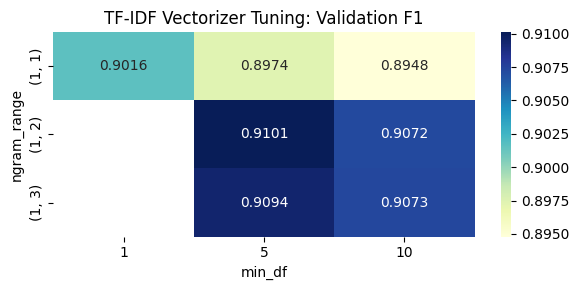

In [ ]:
pivot = vec_df.pivot(index='ngram_range', columns='min_df', values='val_f1')
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('TF-IDF Vectorizer Tuning: Validation F1')
ax.set_xlabel('min_df')
ax.set_ylabel('ngram_range')
plt.tight_layout()
plt.show()

In [17]:
best_vec_row = vec_df.iloc[0]
best_vec_config = {
    'vectorizer_class': 'TfidfVectorizerWrapper',
    'ngram_range':      best_vec_row['ngram_range'],
    'min_df':           int(best_vec_row['min_df']),
}
print('Best vectorizer config:', best_vec_config)

with open('../results/best_vectorizer_config.pkl', 'wb') as f:
    pickle.dump(best_vec_config, f)
print('Saved to results/best_vectorizer_config.pkl')

Best vectorizer config: {'vectorizer_class': 'TfidfVectorizerWrapper', 'ngram_range': (1, 2), 'min_df': 5}
Saved to results/best_vectorizer_config.pkl
